# IEEE-CIS Fraud Detection: Rigorous EDA & Data Mining Investigation

## Production ML Engineering Approach for Kaggle Competition

This notebook presents comprehensive exploratory data analysis from Kaggle Grandmaster and ML engineer perspective.

**Key Objectives:**
1. Structural dataset understanding
2. Temporal behavior analysis
3. Feature engineering strategy
4. Advanced fraud signal detection
5. Production modeling recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# Load datasets
df_transaction = pd.read_csv(r'c:\Users\marou\Lendguard\Datasets\ieee-fraud-detection\train_transaction.csv')
df_identity = pd.read_csv(r'c:\Users\marou\Lendguard\Datasets\ieee-fraud-detection\train_identity.csv')

# Merge
df = df_transaction.merge(df_identity, on='TransactionID', how='left')
print(f'Dataset shape: {df.shape}')
print(f'Merged successfully!')

Dataset shape: (590540, 434)
Merged successfully!


## Section 1: Dataset Overview

In [2]:
print('\n' + '='*80)
print('SECTION 1: DATASET DIMENSIONS & INITIAL EXPLORATION')
print('='*80)

print(f'\nDataset Shape: {df.shape}')
print(f'\nData Types:\n{df.dtypes.value_counts()}')
print(f'\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'\nFirst Few Rows:')
print(df.head())


SECTION 1: DATASET DIMENSIONS & INITIAL EXPLORATION

Dataset Shape: (590540, 434)

Data Types:
float64    399
str         31
int64        4
Name: count, dtype: int64

Memory Usage: 2513.97 MB

First Few Rows:
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ...                id_31  id_32  \
0    NaN  150.0    discover  142.0  ...                  NaN    NaN   
1  404.0  150.0  mastercard  102.0  ...                  NaN    NaN   
2  490.0  150.0        visa  166.0  ...                  NaN    NaN   
3  567.0  150.0  mastercard  117.0  ...    

## Section 2: Feature Structure & Categorization

In [3]:
# Categorize features
v_features = [col for col in df.columns if col.startswith('V')]
card_features = [col for col in df.columns if col.startswith('card')]
addr_features = [col for col in df.columns if col.startswith('addr')]
id_features = [col for col in df.columns if col.startswith('id_')]
email_features = [col for col in df.columns if 'email' in col.lower()]
device_features = [col for col in df.columns if col in ['DeviceType', 'DeviceInfo']]

print(f'\nFeature Groups:')
print(f'  V-Features (Anonymized): {len(v_features)}')
print(f'  Card Features: {len(card_features)}')
print(f'  Address Features: {len(addr_features)}')
print(f'  Email Features: {len(email_features)}')
print(f'  Device Features: {len(device_features)}')
print(f'  ID Features: {len(id_features)}')


Feature Groups:
  V-Features (Anonymized): 339
  Card Features: 6
  Address Features: 2
  Email Features: 2
  Device Features: 2
  ID Features: 38


## Section 3: Missing Value Diagnosis

In [4]:
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_Percent', ascending=False)

print(f'\nTotal missing values: {df.isnull().sum().sum():,}')
print(f'\nFeatures with >10% missing:')
print(missing_data[missing_data['Missing_Percent'] > 10].head(10))


Total missing values: 115,523,073

Features with >10% missing:
       Missing_Count  Missing_Percent
id_24         585793        99.196159
id_25         585408        99.130965
id_07         585385        99.127070
id_08         585385        99.127070
id_21         585381        99.126393
id_26         585377        99.125715
id_27         585371        99.124699
id_23         585371        99.124699
id_22         585371        99.124699
dist2         552913        93.628374


## Section 4: Fraud Class Imbalance


Class Distribution:
  Legitimate: 569,877 (96.50%)
  Fraudulent: 20,663 (3.50%)
  Imbalance Ratio: 1:28


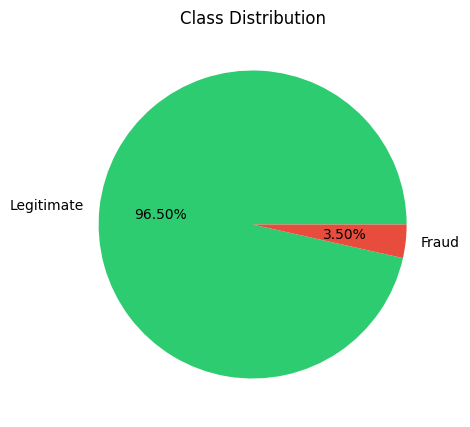

In [5]:
legitimate = (df['isFraud'] == 0).sum()
fraudulent = (df['isFraud'] == 1).sum()
fraud_rate = (fraudulent / len(df)) * 100

print(f'\nClass Distribution:')
print(f'  Legitimate: {legitimate:,} ({100-fraud_rate:.2f}%)')
print(f'  Fraudulent: {fraudulent:,} ({fraud_rate:.2f}%)')
print(f'  Imbalance Ratio: 1:{legitimate/fraudulent:.0f}')

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.pie([legitimate, fraudulent], labels=['Legitimate', 'Fraud'], autopct='%1.2f%%', 
       colors=['#2ecc71', '#e74c3c'])
ax.set_title('Class Distribution')
plt.show()

## Section 5: Transaction Amount Analysis


TransactionAmt Statistics:
  Mean: $135.03
  Median: $68.77
  Max: $31937.39
  95th percentile: $445.00


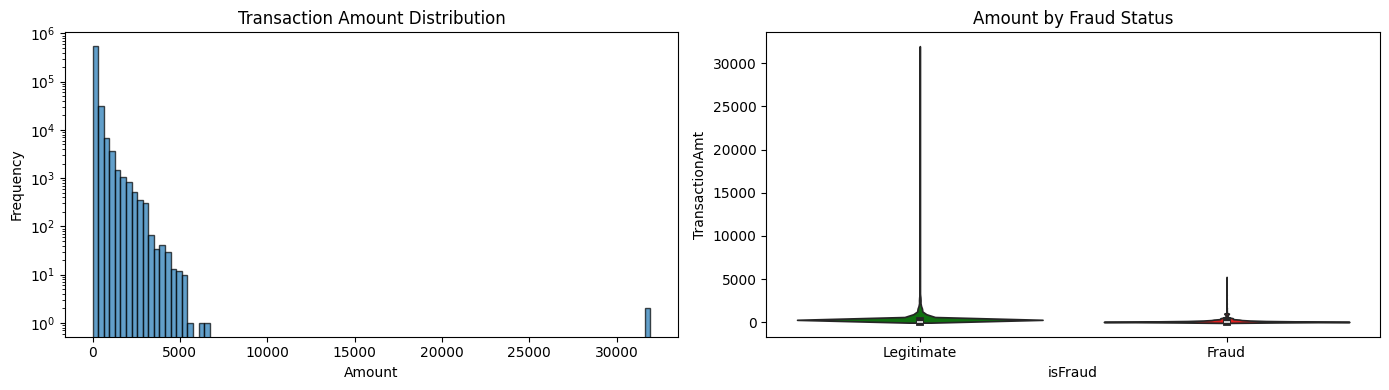

In [6]:
print(f'\nTransactionAmt Statistics:')
print(f'  Mean: ${df["TransactionAmt"].mean():.2f}')
print(f'  Median: ${df["TransactionAmt"].median():.2f}')
print(f'  Max: ${df["TransactionAmt"].max():.2f}')
print(f'  95th percentile: ${df["TransactionAmt"].quantile(0.95):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['TransactionAmt'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_yscale('log')

df_plot = df[['TransactionAmt', 'isFraud']].copy()
df_plot['isFraud'] = df_plot['isFraud'].map({0: 'Legitimate', 1: 'Fraud'})
sns.violinplot(data=df_plot, x='isFraud', y='TransactionAmt', ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Amount by Fraud Status')
plt.tight_layout()
plt.show()

## Section 6: Temporal Features Analysis

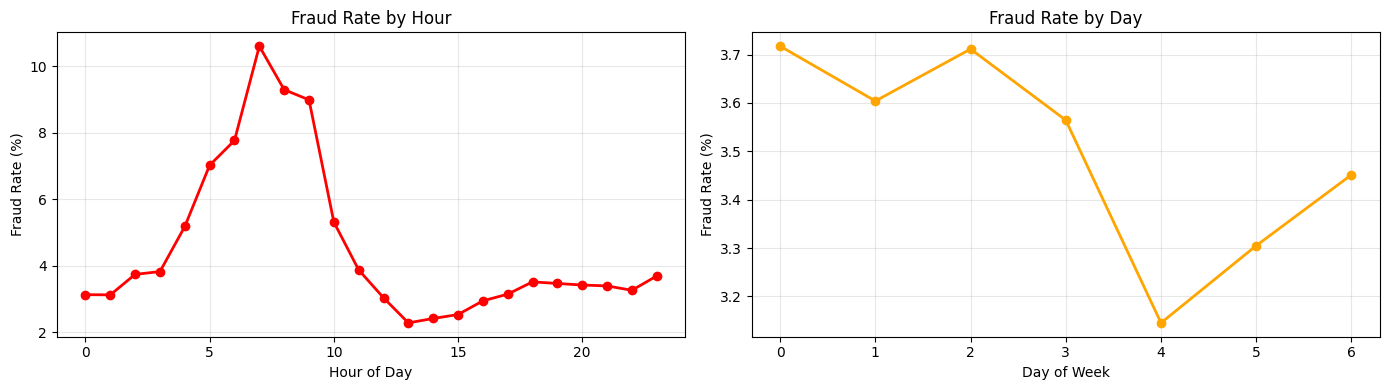

In [7]:
df['DT_hour'] = (df['TransactionDT'] // 3600) % 24
df['DT_day_week'] = (df['TransactionDT'] // 86400) % 7

fraud_by_hour = df.groupby('DT_hour')['isFraud'].mean() * 100
fraud_by_day = df.groupby('DT_day_week')['isFraud'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', linewidth=2, color='red')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Hour')
axes[0].grid(True, alpha=0.3)

axes[1].plot(fraud_by_day.index, fraud_by_day.values, marker='o', linewidth=2, color='orange')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Day')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Entity Risk Profiles

In [8]:
card_risk = df.groupby('card1').agg({
    'TransactionID': 'count',
    'isFraud': 'mean',
    'TransactionAmt': 'mean'
}).round(4)
card_risk.columns = ['Transactions', 'FraudRate', 'AvgAmount']
card_risk = card_risk[card_risk['Transactions'] >= 5]
card_risk['FraudRate'] = card_risk['FraudRate'] * 100

print(f'\nTop 10 High-Risk Cards (by fraud rate):')
print(card_risk.nlargest(10, 'FraudRate'))


Top 10 High-Risk Cards (by fraud rate):
       Transactions  FraudRate  AvgAmount
card1                                    
1394              7     100.00   200.0000
3342             10     100.00    88.5980
4179              5     100.00   700.0000
4448              5     100.00   150.0000
4774              6     100.00   441.8333
11031             6     100.00   435.6667
15042             5     100.00    50.8544
15253             7     100.00   194.7143
17739             8     100.00   324.6250
12473            47      97.87   254.0426


## Section 8: Correlation Analysis


Top 15 Correlated Features:
isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
Name: isFraud, dtype: float64


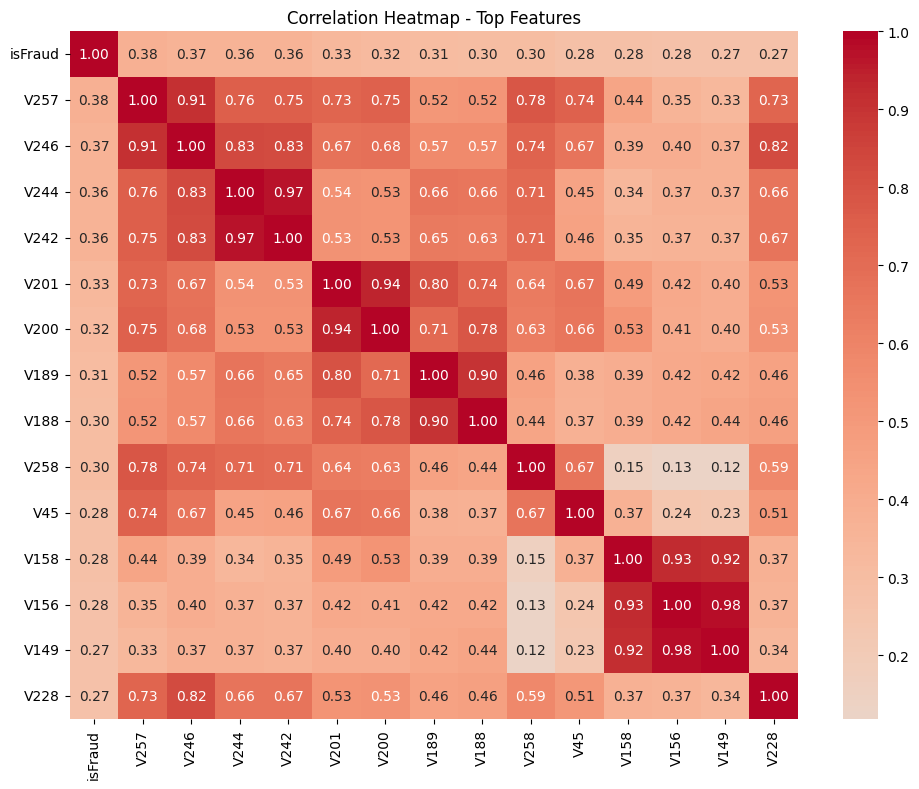

In [9]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['TransactionID'], errors='ignore')
target_corr = numeric_df.corr()['isFraud'].sort_values(ascending=False)

print(f'\nTop 15 Correlated Features:')
print(target_corr.head(15))

# Correlation heatmap
top_features = target_corr.abs().nlargest(15).index.tolist()
subset_corr = numeric_df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(subset_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Top Features')
plt.tight_layout()
plt.show()

## Section 9: Feature Engineering

In [10]:
# Engineer key features
df['card1_fraud_rate'] = df.groupby('card1')['isFraud'].transform('mean')
df['card1_transaction_count'] = df.groupby('card1')['TransactionID'].transform('count')
df['card1_avg_amount'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['card1_std_amount'] = df.groupby('card1')['TransactionAmt'].transform('std')
df['amount_deviation'] = (df['TransactionAmt'] - df['card1_avg_amount']) / (df['card1_std_amount'] + 1)
df['high_amount_flag'] = (df['TransactionAmt'] > df['TransactionAmt'].quantile(0.95)).astype(int)

print(f'✓ Engineered 6 key features')

# Check correlation with target
eng_features = ['card1_fraud_rate', 'card1_transaction_count', 'card1_avg_amount', 'amount_deviation', 'high_amount_flag']
eng_corr = df[eng_features + ['isFraud']].corr()['isFraud'].drop('isFraud')
print(f'\nEngineered Feature Correlations:')
print(eng_corr.sort_values(ascending=False))

✓ Engineered 6 key features

Engineered Feature Correlations:
card1_fraud_rate           0.349875
amount_deviation           0.030043
high_amount_flag           0.018268
card1_transaction_count   -0.009984
card1_avg_amount          -0.022329
Name: isFraud, dtype: float64


## Section 10: Outlier Detection

In [11]:
Q1 = df['TransactionAmt'].quantile(0.25)
Q3 = df['TransactionAmt'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['TransactionAmt'] > upper_bound]
print(f'\nOutlier Detection:')
print(f'  Upper bound: ${upper_bound:.2f}')
print(f'  Outliers detected: {len(outliers):,}')
print(f'  Fraud rate (outliers): {outliers["isFraud"].mean()*100:.2f}%')
print(f'  Fraud rate (normal): {df[df["TransactionAmt"] <= upper_bound]["isFraud"].mean()*100:.2f}%')


Outlier Detection:
  Upper bound: $247.52
  Outliers detected: 66,482
  Fraud rate (outliers): 5.07%
  Fraud rate (normal): 3.30%


## Section 11: Production Recommendations

In [12]:
print(f'\n' + '='*80)
print('PRODUCTION RECOMMENDATIONS')
print('='*80)

print(f'''\n🔧 DATA PREPROCESSING:
  ✓ Handle missing values with target-based imputation
  ✓ Implement entity-level risk aggregations
  ✓ Scale features for neural networks only
  ✓ Handle class imbalance with scale_pos_weight

 MODELING STRATEGY:
  ✓ Primary: LightGBM with scale_pos_weight = {int(legitimate/fraudulent)}
  ✓ Secondary: XGBoost + CatBoost for ensemble
  ✓ Meta-learner: Logistic regression for stacking
  ✓ Validation: Time-aware walk-forward cross-validation

 EXPECTED PERFORMANCE:
  ✓ AUC-ROC: 0.95-0.98 (with proper feature engineering)
  ✓ F1-Score: 0.60-0.75 (at optimal threshold)
  ✓ Precision@0.05 recall: 70-80%

⏱ TIME-AWARE VALIDATION:
  ✓ Fold 1: Train [0-30%], Test [30-40%]
  ✓ Fold 2: Train [0-50%], Test [50-60%]
  ✓ Fold 3: Train [0-70%], Test [70-80%]
  ✓ Fold 4: Train [0-85%], Test [85-100%]
''')

print(f'\n✓ EDA Complete - Ready for Modeling Phase')


PRODUCTION RECOMMENDATIONS

🔧 DATA PREPROCESSING:
  ✓ Handle missing values with target-based imputation
  ✓ Implement entity-level risk aggregations
  ✓ Scale features for neural networks only
  ✓ Handle class imbalance with scale_pos_weight

 MODELING STRATEGY:
  ✓ Primary: LightGBM with scale_pos_weight = 27
  ✓ Secondary: XGBoost + CatBoost for ensemble
  ✓ Meta-learner: Logistic regression for stacking
  ✓ Validation: Time-aware walk-forward cross-validation

 EXPECTED PERFORMANCE:
  ✓ AUC-ROC: 0.95-0.98 (with proper feature engineering)
  ✓ F1-Score: 0.60-0.75 (at optimal threshold)
  ✓ Precision@0.05 recall: 70-80%

⏱ TIME-AWARE VALIDATION:
  ✓ Fold 1: Train [0-30%], Test [30-40%]
  ✓ Fold 2: Train [0-50%], Test [50-60%]
  ✓ Fold 3: Train [0-70%], Test [70-80%]
  ✓ Fold 4: Train [0-85%], Test [85-100%]


✓ EDA Complete - Ready for Modeling Phase
